# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
!pip install -q ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
adult_income = fetch_ucirepo(id=2)

In [4]:
X = adult_income.data.features
y = adult_income.data.targets

df = pd.concat([X, y], axis=1)

from pathlib import Path
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
df.to_csv(data_dir / "census_income.csv", index=False)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.shape

(48842, 15)

In [6]:
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [7]:
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace("-", "_", regex=False))

print("Informasi data:")
df.info()

print("\nStatistik deskriptif:")
display(df.describe(include="all").T)

missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("\nVariabel yang memiliki missing value:")
display(missing_values.to_frame(name="jumlah_missing"))

Informasi data:
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education_num   48842 non-null  int64
 5   marital_status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital_gain    48842 non-null  int64
 11  capital_loss    48842 non-null  int64
 12  hours_per_week  48842 non-null  int64
 13  native_country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB

Statistik deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,47879,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital_status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,47876,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Variabel yang memiliki missing value:


,jumlah_missing
occupation,966
workclass,963
native_country,274


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [8]:
for column in missing_values.index:
    df[column] = df[column].fillna(df[column].mode()[0])

remaining_missing = df.isna().sum()
print("Total missing value setelah imputasi:", remaining_missing.sum())
display(remaining_missing.to_frame(name="jumlah_missing"))

Total missing value setelah imputasi: 0


,jumlah_missing
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [9]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

print("Kategori sebelum penyesuaian:")
for column in categorical_columns:
    print(f"{column}: {sorted(df[column].dropna().unique())}")

for column in categorical_columns:
    df[column] = df[column].str.strip()

df[categorical_columns] = df[categorical_columns].replace("?", "Others")
df["income"] = df["income"].str.rstrip(".")
df["native_country"] = df["native_country"].replace({
    "Holand-Netherlands": "Holland-Netherlands",
    "Trinadad&Tobago": "Trinidad&Tobago"
})

print("\nKategori setelah penyesuaian:")
for column in categorical_columns:
    print(f"{column}: {sorted(df[column].unique())}")

Kategori sebelum penyesuaian:
workclass: ['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']
education: ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']


marital_status: ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']
occupation: ['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']
relationship: ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']
race: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']
sex: ['Female', 'Male']
native_country: ['?', 'Cambodia', 'Canada', 'China', 'Columbia', 'Cuba', 'Dominican-Republic', 'Ecuador', 'El-Salvador', 'England', 'France', 'Germany', 'Greece', 'Guatemala', 'Haiti', 'Holand-Netherlands', 'Honduras', 'Hong', 'Hungary', 'India', 'Iran', 'Ireland', 'Italy', 'Jamaica', 'Japan', 'Laos', 'Mexico', 'Nicaragua', 'Outlying-US(Guam-USVI-etc)', 'Peru', 'Philippines', 'Poland', 'Portugal', 

income: ['<=50K', '<=50K.', '>50K', '>50K.']



Kategori setelah penyesuaian:
workclass: ['Federal-gov', 'Local-gov', 'Never-worked', 'Others', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']
education: ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']
marital_status: ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']
occupation: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Others', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']
relationship: ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']
race: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']
sex: ['Female', 'Male']
native_country: ['Cambodia', 

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

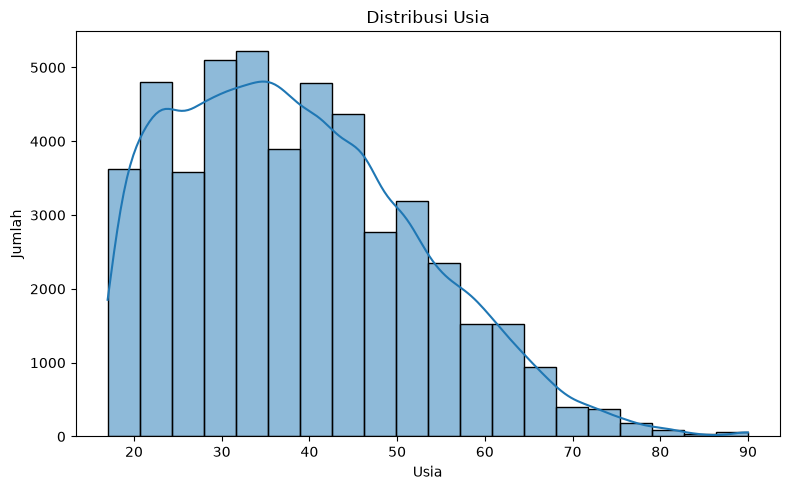

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=20, kde=True)
plt.title("Distribusi Usia")
plt.xlabel("Usia")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

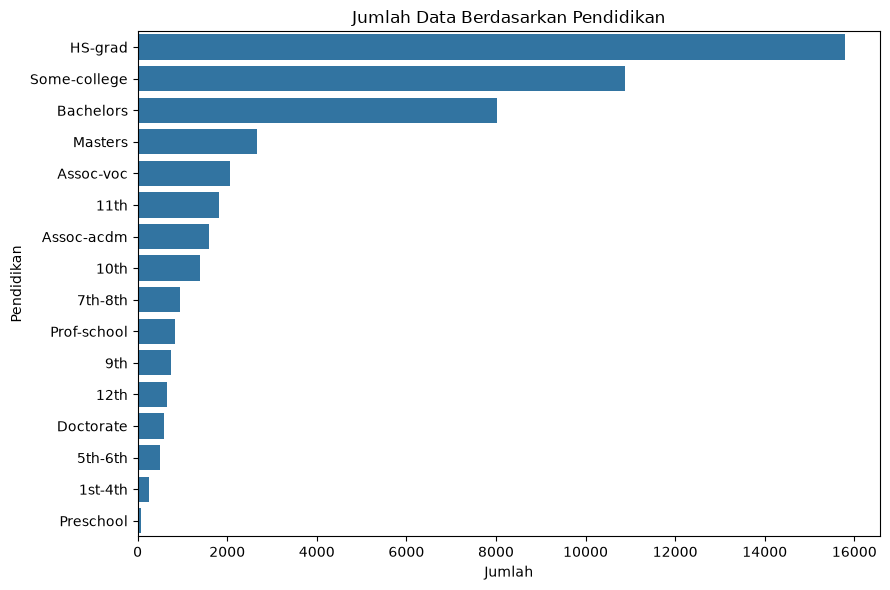

In [11]:
education_order = df["education"].value_counts().index
plt.figure(figsize=(9, 6))
sns.countplot(data=df, y="education", order=education_order)
plt.title("Jumlah Data Berdasarkan Pendidikan")
plt.xlabel("Jumlah")
plt.ylabel("Pendidikan")
plt.tight_layout()
plt.show()

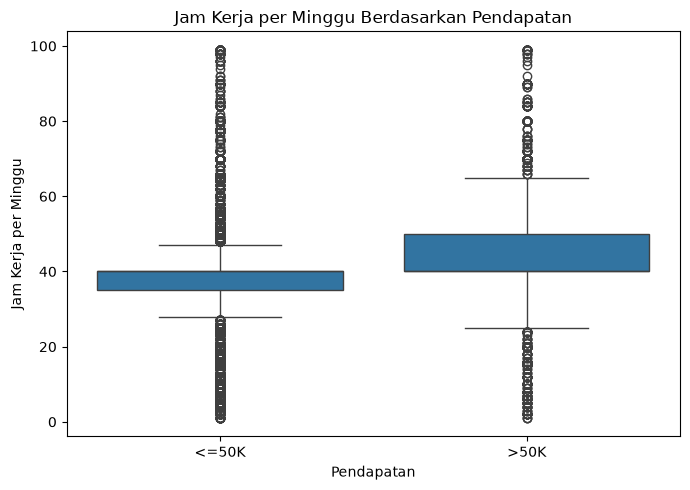

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="income", y="hours_per_week")
plt.title("Jam Kerja per Minggu Berdasarkan Pendapatan")
plt.xlabel("Pendapatan")
plt.ylabel("Jam Kerja per Minggu")
plt.tight_layout()
plt.show()

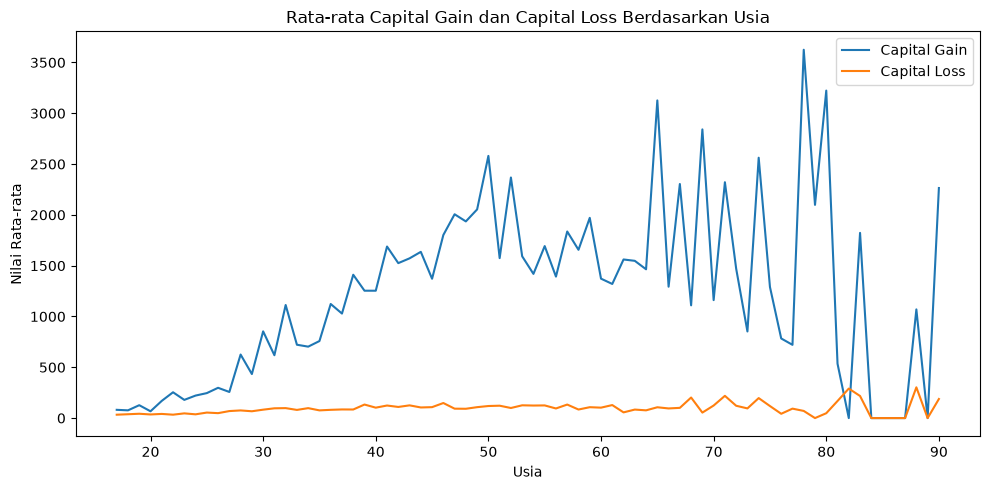

In [13]:
age_capital = (df.groupby("age", as_index=False)
               [["capital_gain", "capital_loss"]].mean())

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_capital, x="age", y="capital_gain", label="Capital Gain")
sns.lineplot(data=age_capital, x="age", y="capital_loss", label="Capital Loss")
plt.title("Rata-rata Capital Gain dan Capital Loss Berdasarkan Usia")
plt.xlabel("Usia")
plt.ylabel("Nilai Rata-rata")
plt.tight_layout()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [14]:
outlier_counts = {}
for income_category, group in df.groupby("income"):
    q1 = group["hours_per_week"].quantile(0.25)
    q3 = group["hours_per_week"].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_counts[income_category] = int(
        ((group["hours_per_week"] < lower_bound) |
         (group["hours_per_week"] > upper_bound)).sum()
    )

print("Jumlah outlier hours_per_week:")
display(pd.Series(outlier_counts, name="jumlah_outlier").to_frame())

# 1. Distribusi age miring ke kanan. Sebagian besar usia berada pada rentang dewasa muda sampai paruh baya, sedangkan jumlah data menurun pada usia lanjut.
# 2. Jika age memiliki missing value, median digunakan karena distribusinya miring ke kanan dan median lebih tahan terhadap nilai ekstrem dibandingkan mean.
# 3. Berdasarkan metode IQR pada setiap kategori income, kategori <=50K memiliki 11.706 outlier dan kategori >50K memiliki 781 outlier. Kategori <=50K memiliki jumlah outlier paling banyak.

Jumlah outlier hours_per_week:


,jumlah_outlier
<=50K,11706
>50K,781


# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [15]:
from sklearn.preprocessing import LabelEncoder

sex_encoder = LabelEncoder()
income_encoder = LabelEncoder()

df["sex"] = sex_encoder.fit_transform(df["sex"])
df["income"] = income_encoder.fit_transform(df["income"])

print("Encoding sex:", dict(zip(sex_encoder.classes_, sex_encoder.transform(sex_encoder.classes_))))
print("Encoding income:", dict(zip(income_encoder.classes_, income_encoder.transform(income_encoder.classes_))))
display(df[["sex", "income"]].head())

Encoding sex: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoding income: {'<=50K': np.int64(0), '>50K': np.int64(1)}


,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

,age,education_num,hours_per_week,capital_gain,capital_loss,income
age,1.0000,0.0309,0.0716,0.0772,0.0569,0.2304
education_num,0.0309,1.0000,0.1437,0.1251,0.0810,0.3326
hours_per_week,0.0716,0.1437,1.0000,0.0822,0.0545,0.2277
capital_gain,0.0772,0.1251,0.0822,1.0000,-0.0314,0.2230
capital_loss,0.0569,0.0810,0.0545,-0.0314,1.0000,0.1476
income,0.2304,0.3326,0.2277,0.2230,0.1476,1.0000


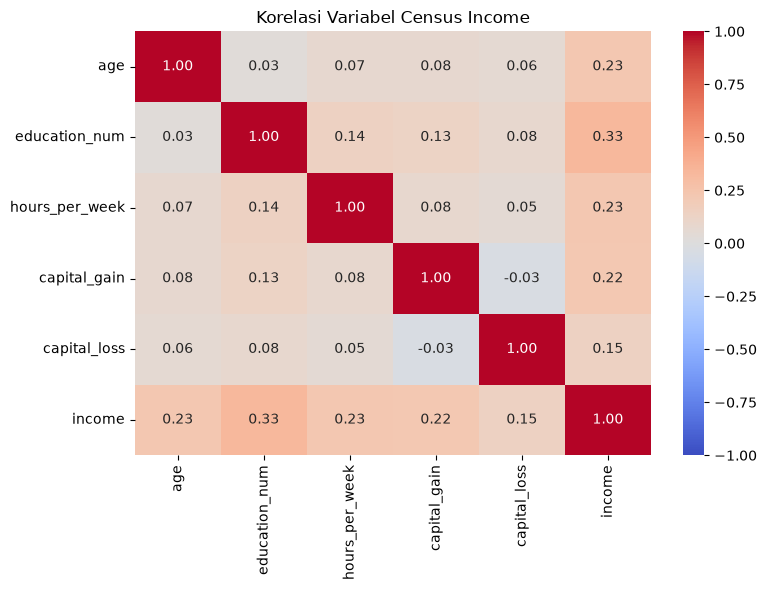

In [16]:
correlation_columns = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain",
    "capital_loss",
    "income"
]

correlation_matrix = df[correlation_columns].corr()
display(correlation_matrix.round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Variabel Census Income")
plt.tight_layout()
plt.show()

In [17]:
# Education_num memiliki korelasi positif paling kuat dengan income, yaitu 0,33. Age, hours_per_week, dan capital_gain memiliki korelasi positif sekitar 0,22 sampai 0,23, sedangkan capital_loss memiliki korelasi paling lemah, yaitu 0,15. Semua korelasi terhadap income tergolong lemah sampai sedang.

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [18]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = mnist.load_data()

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
np.savez_compressed(data_dir / "mnist_test.npz", X_test=X_test, y_test=y_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


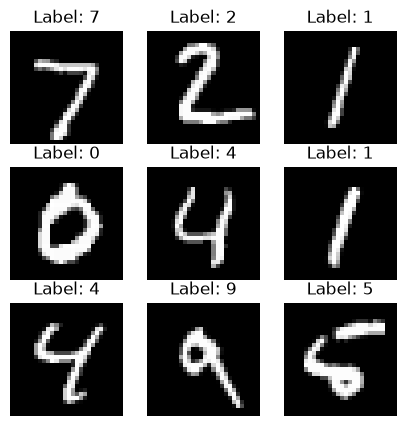

In [19]:
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Ukuran data setelah upsampling: (10000, 32, 32)


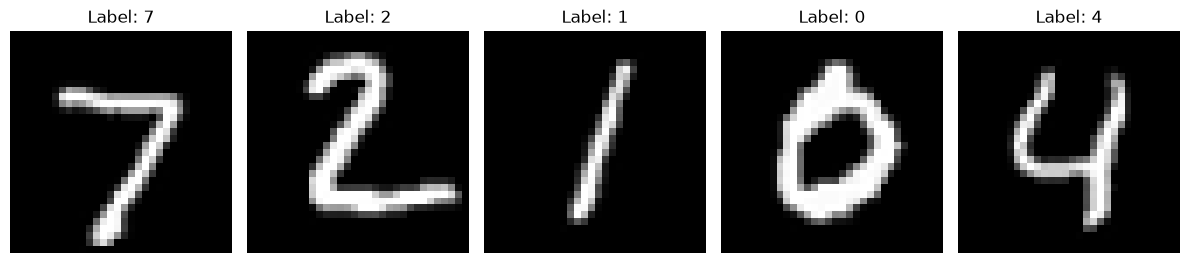

In [20]:
import cv2

X_test_resized = np.empty((X_test.shape[0], 32, 32), dtype=np.uint8)

for i, image in enumerate(X_test):
    X_test_resized[i] = cv2.resize(image, (32, 32), interpolation=cv2.INTER_CUBIC)

print("Ukuran data setelah upsampling:", X_test_resized.shape)

plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_resized[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [21]:
X_test_normalized = X_test_resized.astype(np.float32) / 255.0

print("Ukuran data:", X_test_normalized.shape)
print("Nilai minimum:", X_test_normalized.min())
print("Nilai maksimum:", X_test_normalized.max())

Ukuran data: (10000, 32, 32)
Nilai minimum: 0.0
Nilai maksimum: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [22]:
X_test_flattened = np.empty(
    (X_test_normalized.shape[0], 32 * 32),
    dtype=np.float32
)

for i, image in enumerate(X_test_normalized):
    X_test_flattened[i] = image.flatten()

print("Ukuran data setelah diubah menjadi array 1 dimensi:", X_test_flattened.shape)

Ukuran data setelah diubah menjadi array 1 dimensi: (10000, 1024)
